In [31]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/house-prices-advanced-regression-techniques/sample_submission.csv
/kaggle/input/competitions/house-prices-advanced-regression-techniques/data_description.txt
/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv
/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv


In [32]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [33]:
df=pd.read_csv('/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv')[['FireplaceQu','GarageType','SalePrice']]

In [34]:
df.head()

,FireplaceQu,GarageType,SalePrice
0,NaN,Attchd,208500
1,TA,Attchd,181500
2,TA,Attchd,223500
3,Gd,Detchd,140000
4,TA,Attchd,250000


In [35]:
df.isnull().mean()*100

FireplaceQu    47.260274
GarageType      5.547945
SalePrice       0.000000
dtype: float64

## GarageType

<Axes: xlabel='GarageType'>

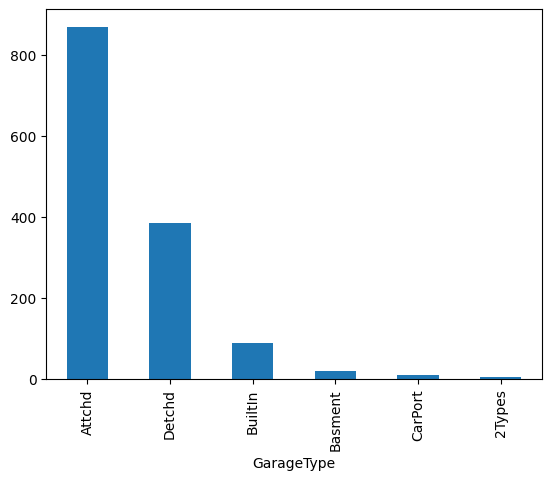

In [36]:
df['GarageType'].value_counts().plot(kind='bar')

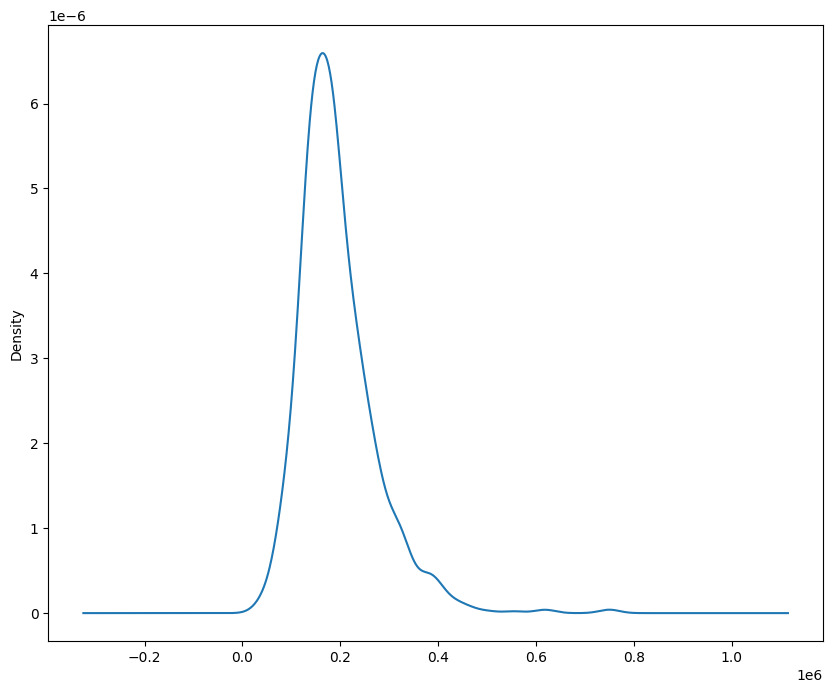

In [45]:
fig=plt.figure(figsize=(10,8))
ax=fig.add_subplot(111)


df[df['GarageType']=='Attchd']['SalePrice'].plot(kind='kde',ax=ax)


plt.show()

In [38]:
temp=df[df['GarageType']=='Attchd']['SalePrice']

In [39]:
df['GarageType']=df['GarageType'].fillna('Attchd')

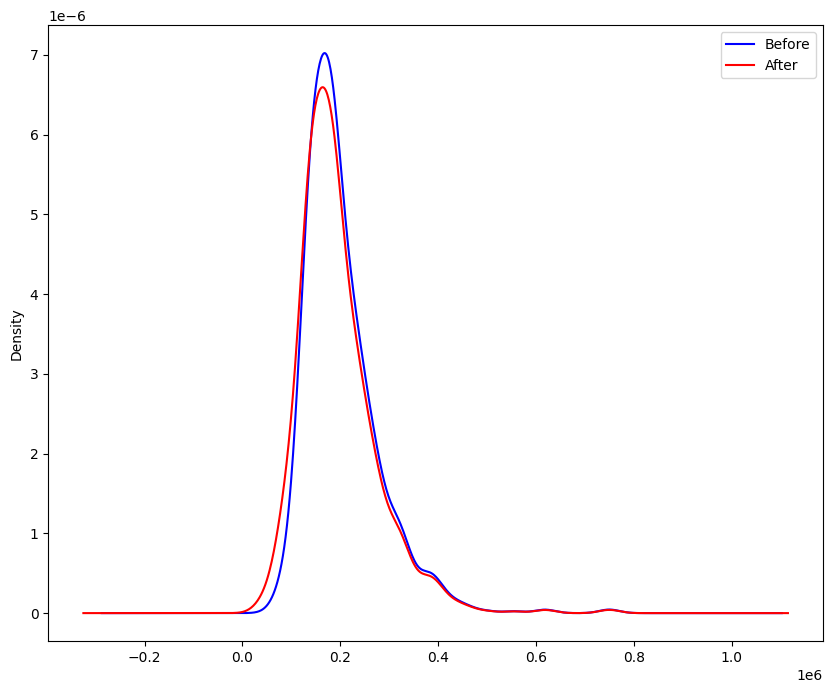

In [43]:
fig=plt.figure(figsize=(10,8))
ax=fig.add_subplot(111)

temp.plot(kind='kde',ax=ax,color='blue',label='Before')

df[df['GarageType']=='Attchd']['SalePrice'].plot(kind='kde',ax=ax,color='red',label='After')

plt.legend()

plt.show()

In [46]:
df.head()

,FireplaceQu,GarageType,SalePrice
0,NaN,Attchd,208500
1,TA,Attchd,181500
2,TA,Attchd,223500
3,Gd,Detchd,140000
4,TA,Attchd,250000


<Axes: xlabel='FireplaceQu'>

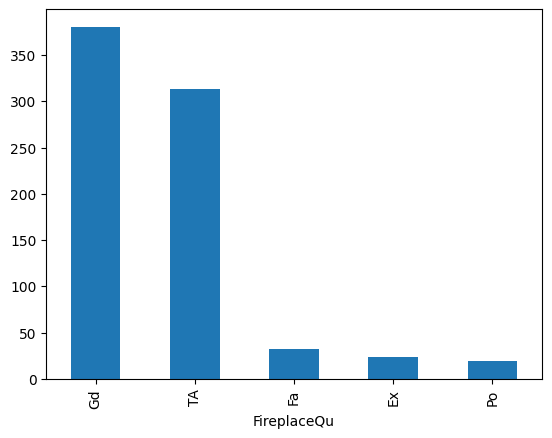

In [47]:
df['FireplaceQu'].value_counts().plot(kind='bar')

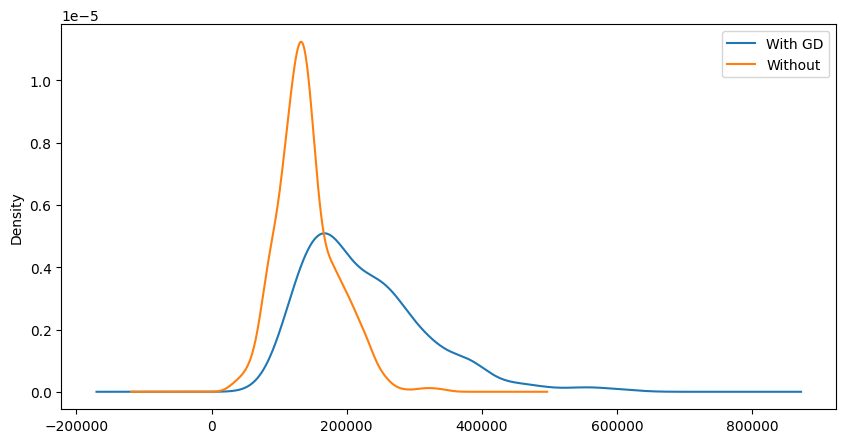

In [50]:
plt.figure(figsize=(10,5))
plt.subplot(111)

df[df['FireplaceQu']=='Gd']['SalePrice'].plot(kind='kde',label='With GD')

df[df['FireplaceQu'].isnull()]['SalePrice'].plot(kind='kde',label='Without')
plt.legend()

In [51]:
temp1=df[df['FireplaceQu']=='Gd']['SalePrice']

In [53]:
df['FireplaceQu']=df['FireplaceQu'].fillna('Gd') 

In [58]:
df['FireplaceQu'].isnull().sum()

np.int64(0)

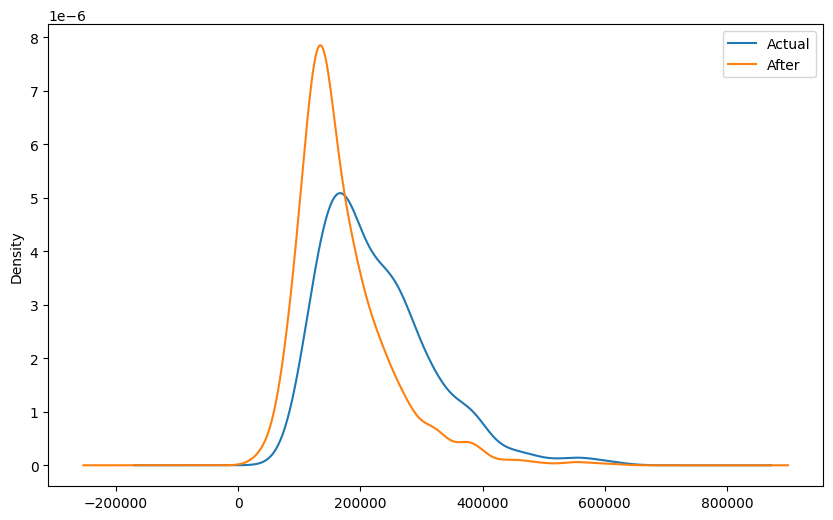

In [60]:
plt.figure(figsize=(10,6))
plt.subplot(111)

temp1.plot(kind='kde',label='Actual')

df[df['FireplaceQu']=='Gd']['SalePrice'].plot(kind='kde',label='After')
plt.legend()
plt.show()

# Using Scikit Learn

In [61]:
df1=pd.read_csv('/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv')[['FireplaceQu','GarageType','SalePrice']]

In [62]:
df1

,FireplaceQu,GarageType,SalePrice
0,NaN,Attchd,208500
1,TA,Attchd,181500
2,TA,Attchd,223500
3,Gd,Detchd,140000
4,TA,Attchd,250000
...,...,...,...
1455,TA,Attchd,175000
1456,TA,Attchd,210000
1457,Gd,Attchd,266500
1458,NaN,Attchd,142125


In [63]:
df1.isnull().mean()*100

FireplaceQu    47.260274
GarageType      5.547945
SalePrice       0.000000
dtype: float64

In [69]:
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

x=df1[['FireplaceQu','GarageType']]
y=df1['SalePrice']

In [71]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)

In [72]:
x_train.isnull().sum()

FireplaceQu    553
GarageType      60
dtype: int64

In [73]:
si=SimpleImputer(strategy='most_frequent')

In [75]:
x_train_transformed=si.fit_transform(x_train)
x_test_transformed=si.transform(x_test)

In [82]:
pd.isnull(x_train_transformed).sum()

np.int64(0)

In [84]:
x_train_transformed.dtype

dtype('O')